# AgroScan Model Comparison

This notebook mirrors `Model_Comparison.ipynb` (PlantVillage / Colab) for the **AgroScan** local datasets and models.

**Datasets (already split, ImageFolder):**
- Level 1 `Datasets/leaf_gate/{train,valid,test}` — leaf vs non-leaf
- Level 2 `Datasets/leaf_type/{train,valid,test}` — 27 crops
- Level 3 `Datasets/{train,valid,test}` — **123** disease classes (~241k / 30k / 30k)

**Level-3 models compared:** EfficientNet-B3, ResNet-50, DenseNet-121  
(same ensemble as `agroscan/config.py`). Training uses focal loss (γ=2) and a class-balanced sampler.

Outputs save under `models/Model_Comparison/`. Full training on ~241k images takes many hours on an RTX 3060 — set `RUN_TRAINING = False` to only rebuild plots from saved checkpoints.

Cell 1: GPU check

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path(r"I:\Agroscan")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA capability:", torch.cuda.get_device_capability(0))
else:
    print("No GPU. Training will be very slow on CPU.")

GPU available: True
GPU name: NVIDIA GeForce RTX 3060
CUDA capability: (8, 6)


Cell 2: Install optional libraries (skip if already in the project venv)

In [2]:
# Uncomment if needed:
# %pip install tqdm scikit-learn matplotlib pandas pillow grad-cam
print("Using project packages (torch, torchvision, sklearn, matplotlib, pandas).")

Using project packages (torch, torchvision, sklearn, matplotlib, pandas).


Cell 3: Paths and save folder

In [3]:
import json
import os
import random
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

ROOT = Path(r"I:\Agroscan")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATASETS = ROOT / "Datasets"
DISEASE = {
    "train": DATASETS / "train",
    "valid": DATASETS / "valid",
    "test": DATASETS / "test",
}
LEAF_GATE = DATASETS / "leaf_gate"
LEAF_TYPE = DATASETS / "leaf_type"
SAVE_DIR = ROOT / "models" / "Model_Comparison"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

IMG_EXTS = {".jpg", ".jpeg", ".jpe", ".jfif", ".png", ".bmp", ".webp", ".gif", ".tif", ".tiff"}

# Set False to skip the long 3-model training loop and load checkpoints instead.
RUN_TRAINING = False

print("DATASETS:", DATASETS)
print("SAVE_DIR:", SAVE_DIR)
print("RUN_TRAINING:", RUN_TRAINING)

DATASETS: I:\Agroscan\Datasets
SAVE_DIR: I:\Agroscan\models\Model_Comparison
RUN_TRAINING: False


Cell 4: Dataset structure check

In [4]:
def list_top(path: Path, depth=2):
    if not path.exists():
        print("MISSING", path)
        return
    print(path)
    for p in sorted(path.iterdir()):
        extra = ""
        if p.is_dir():
            n = sum(1 for x in p.iterdir() if x.is_dir())
            extra = f"  ({n} subdirs)"
        print(" ", p.name + extra)

print("=== Datasets root ===")
list_top(DATASETS)
print("\n=== leaf_gate/train ===")
list_top(LEAF_GATE / "train")
print("\n=== leaf_type/train (crops) ===")
list_top(LEAF_TYPE / "train")
print("\n=== disease train (first 15 classes) ===")
for i, p in enumerate(sorted((DATASETS / "train").iterdir())):
    if i >= 15:
        print("  ...")
        break
    print(" ", p.name)

=== Datasets root ===
I:\Agroscan\Datasets
  geospatial  (1 subdirs)
  leaf_gate  (3 subdirs)
  leaf_type  (3 subdirs)
  llm  (1 subdirs)
  notebooks  (0 subdirs)
  README.md
  sources  (2 subdirs)
  split_build_log.txt
  split_counts_disease.txt
  split_counts_leaf_gate.txt
  tabular  (1 subdirs)
  test  (123 subdirs)
  train  (123 subdirs)
  valid  (123 subdirs)

=== leaf_gate/train ===
I:\Agroscan\Datasets\leaf_gate\train
  leaf  (0 subdirs)
  non_leaf  (0 subdirs)

=== leaf_type/train (crops) ===
I:\Agroscan\Datasets\leaf_type\train
  Apple  (0 subdirs)
  Banana  (0 subdirs)
  Bean  (0 subdirs)
  Blueberry  (0 subdirs)
  Cauliflower  (0 subdirs)
  Cherry  (0 subdirs)
  Corn  (0 subdirs)
  Cotton  (0 subdirs)
  Grape  (0 subdirs)
  Guava  (0 subdirs)
  Jute  (0 subdirs)
  Mango  (0 subdirs)
  Orange  (0 subdirs)
  Papaya  (0 subdirs)
  Peach  (0 subdirs)
  Pepper  (0 subdirs)
  Potato  (0 subdirs)
  Raspberry  (0 subdirs)
  Red Amaranth  (0 subdirs)
  Rice  (0 subdirs)
  Soybean  (0

Cell 5: Scan ImageFolder splits into a dataframe (paths only, no decode)

In [ ]:
def is_image_file(path: Path) -> bool:
    return path.is_file() and path.suffix.lower() in IMG_EXTS


def scan_imagefolder(root: Path, split: str, level: str) -> pd.DataFrame:
    rows = []
    if not root.is_dir():
        return pd.DataFrame(rows)
    for class_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        for img_path in class_dir.rglob("*"):
            if is_image_file(img_path):
                rows.append({
                    "filepath": str(img_path),
                    "label": class_dir.name,
                    "split": split,
                    "level": level,
                })
    return pd.DataFrame(rows)


disease_parts = [
    scan_imagefolder(DISEASE[s], s, "disease") for s in ("train", "valid", "test")
]
df = pd.concat(disease_parts, ignore_index=True)

class_names = sorted(df["label"].unique().tolist())
label_to_idx = {label: i for i, label in enumerate(class_names)}
idx_to_label = {i: label for label, i in label_to_idx.items()}
df["label_idx"] = df["label"].map(label_to_idx)
num_classes = len(class_names)

print("Disease images:", len(df))
print("Disease classes:", num_classes)
print(df.groupby("split").size())
print("First 10 classes:", class_names[:10])

with open(SAVE_DIR / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, indent=2, ensure_ascii=False)

df.head()

Cell 6: Level 1 / Level 2 inventory

In [9]:
leaf_df = pd.concat(
    [scan_imagefolder(LEAF_GATE / s, s, "leaf_gate") for s in ("train", "valid", "test")],
    ignore_index=True,
)
crop_df = pd.concat(
    [scan_imagefolder(LEAF_TYPE / s, s, "leaf_type") for s in ("train", "valid", "test")],
    ignore_index=True,
)

print("Leaf gate:", len(leaf_df), "images,", leaf_df["label"].nunique(), "classes")
print(leaf_df.groupby(["split", "label"]).size().unstack(fill_value=0))
print("\nLeaf type:", len(crop_df), "images,", crop_df["label"].nunique(), "crops")
print(crop_df[crop_df["split"] == "train"]["label"].value_counts().head(15))

Leaf gate: 16250 images, 2 classes
label  leaf  non_leaf
split                
test    650       975
train  5200      7800
valid   650       975

Leaf type: 302973 images, 27 crops
label
Tomato         47707
Corn           26328
Potato         17364
Guava          16284
Rice           15314
Papaya         14504
Banana         12046
Mango          11805
Grape          10582
Apple          10531
Orange          6416
Soybean         6146
Pepper          5989
Cauliflower     5888
Peach           5781
Name: count, dtype: int64


Cell 7: Graph 1 — Disease class distribution (train)

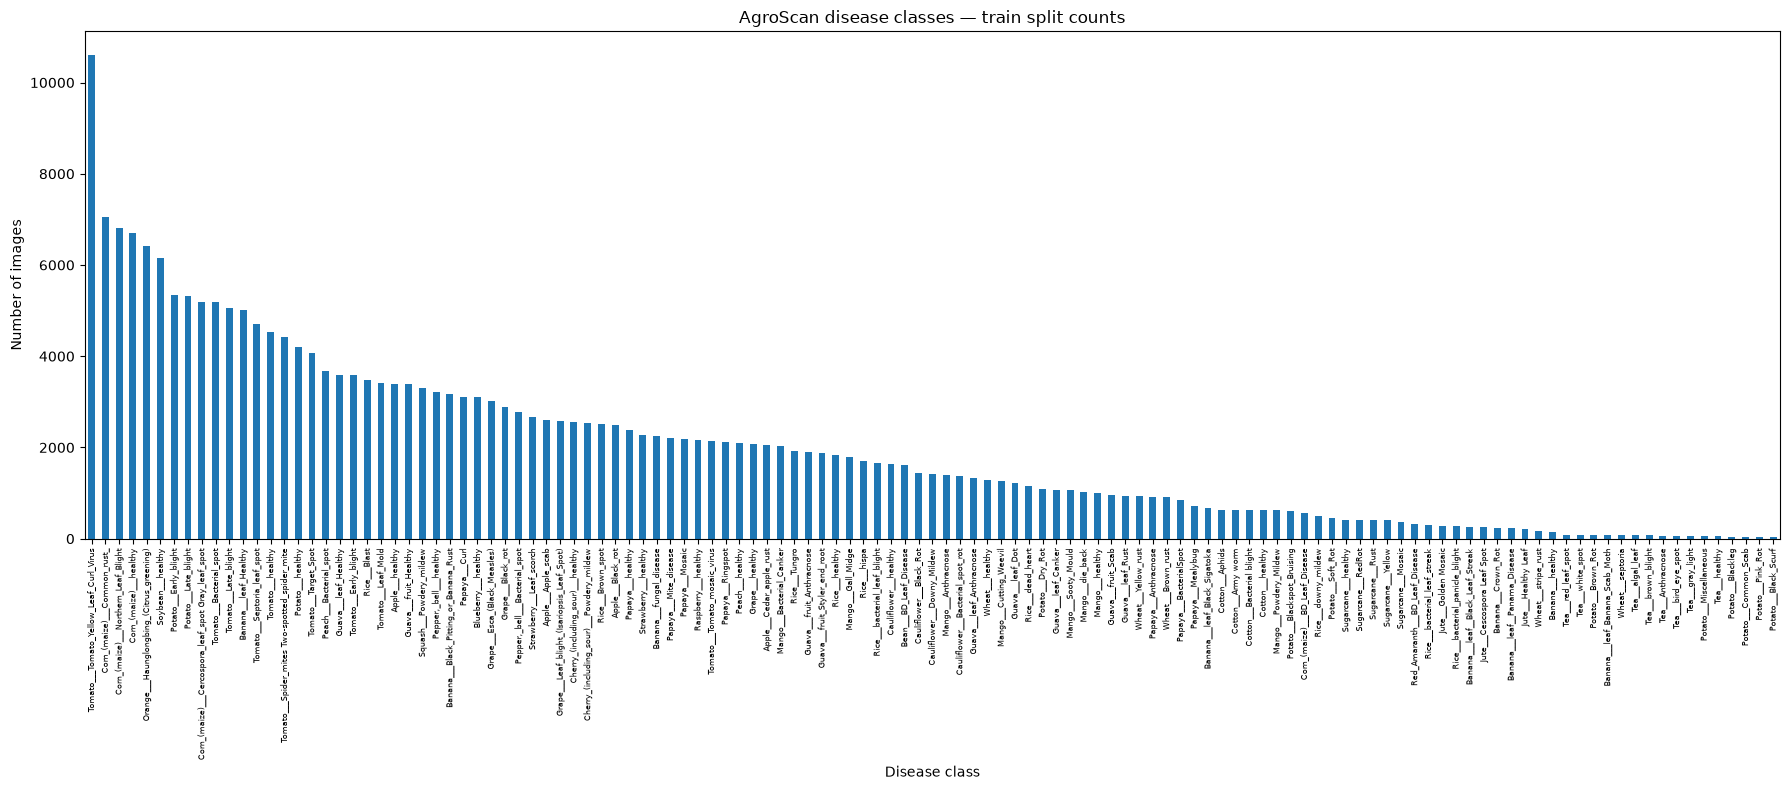

Saved: C:\Agroscan\models\Model_Comparison\01_class_distribution_bar.png
min: 41 max: 10593 ratio: 258.4


In [10]:
import matplotlib.pyplot as plt

train_df = df[df["split"] == "train"].copy()
class_counts = train_df["label"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(18, 8))
class_counts.plot(kind="bar")
plt.title("AgroScan disease classes — train split counts")
plt.xlabel("Disease class")
plt.ylabel("Number of images")
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
path = SAVE_DIR / "01_class_distribution_bar.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", path)
print("min:", int(class_counts.min()), "max:", int(class_counts.max()),
      "ratio:", round(float(class_counts.max() / max(class_counts.min(), 1)), 1))

Cell 8: Graph 2 — Class distribution percentage

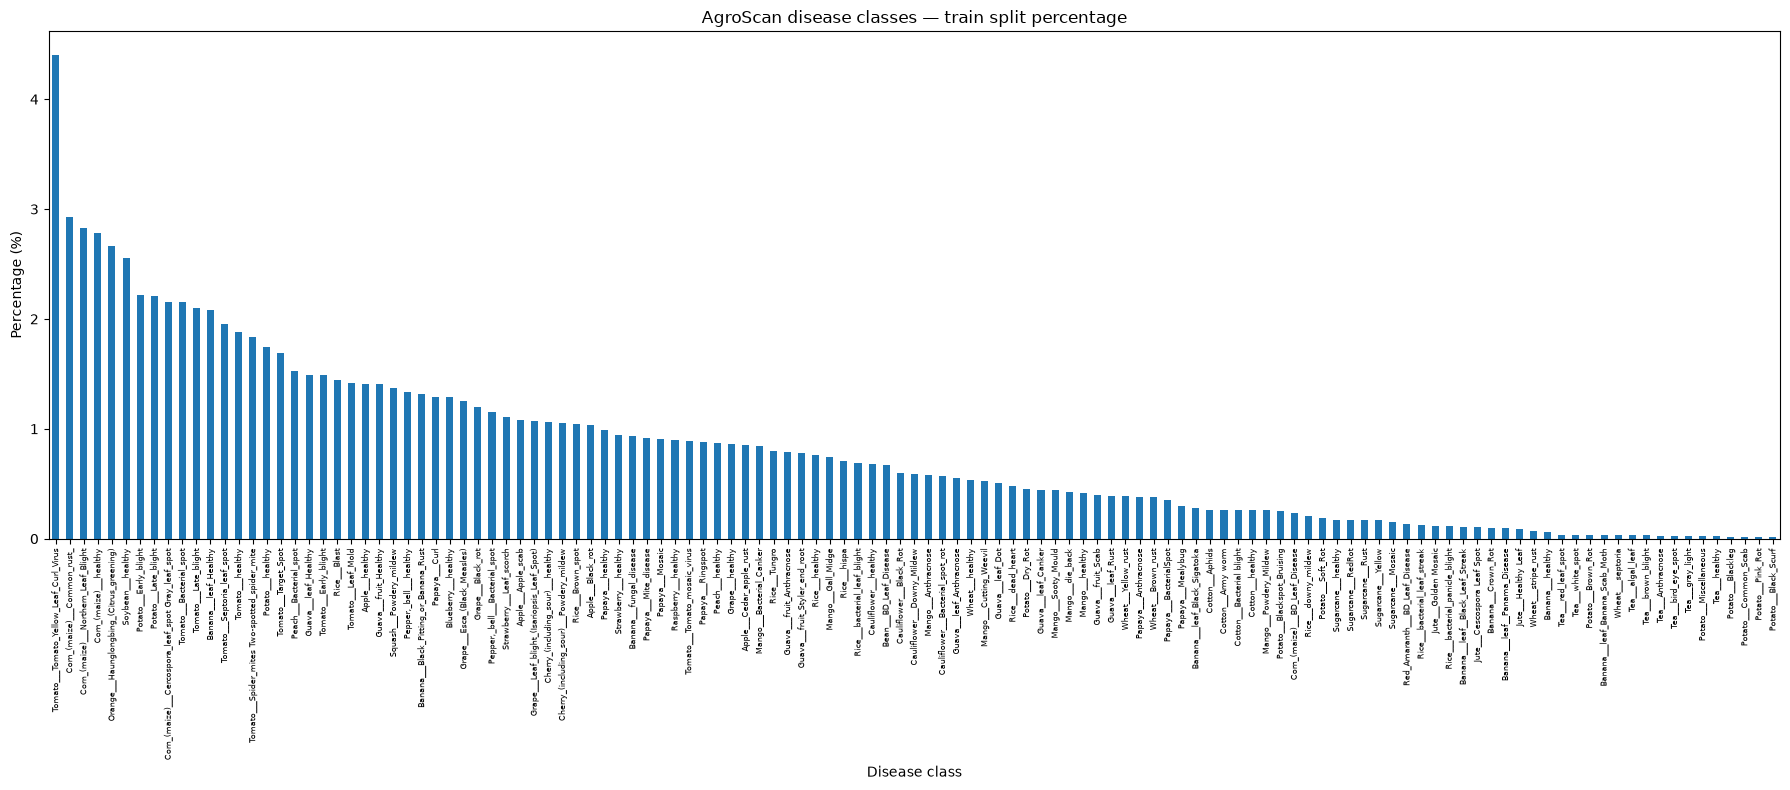

Saved: C:\Agroscan\models\Model_Comparison\02_class_distribution_percentage.png


In [10]:
class_percent = (train_df["label"].value_counts(normalize=True) * 100).sort_values(ascending=False)

plt.figure(figsize=(18, 8))
class_percent.plot(kind="bar")
plt.title("AgroScan disease classes — train split percentage")
plt.xlabel("Disease class")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
path = SAVE_DIR / "02_class_distribution_percentage.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", path)

Cell 9: Graph 3 — Crop (leaf type) distribution

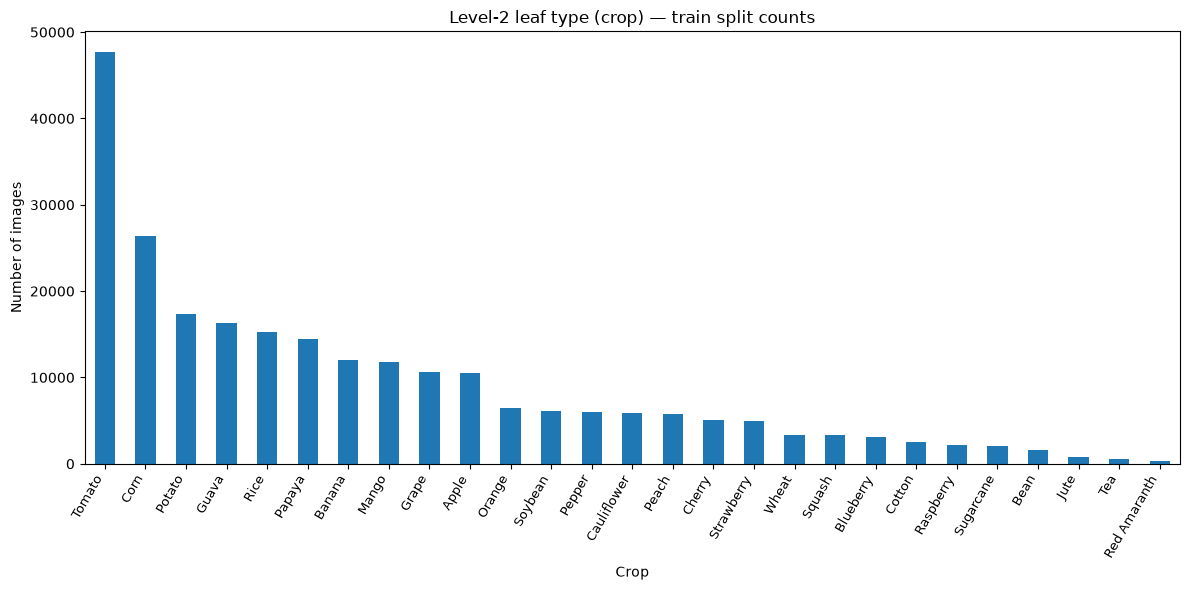

Saved: C:\Agroscan\models\Model_Comparison\02b_crop_distribution_bar.png
Crops: 27


In [11]:
crop_counts = crop_df[crop_df["split"] == "train"]["label"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
crop_counts.plot(kind="bar")
plt.title("Level-2 leaf type (crop) — train split counts")
plt.xlabel("Crop")
plt.ylabel("Number of images")
plt.xticks(rotation=60, ha="right", fontsize=9)
plt.tight_layout()
path = SAVE_DIR / "02b_crop_distribution_bar.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", path)
print("Crops:", len(crop_counts))

Cell 10: Graph 4 — Image width/height (sampled, not all 300k files)

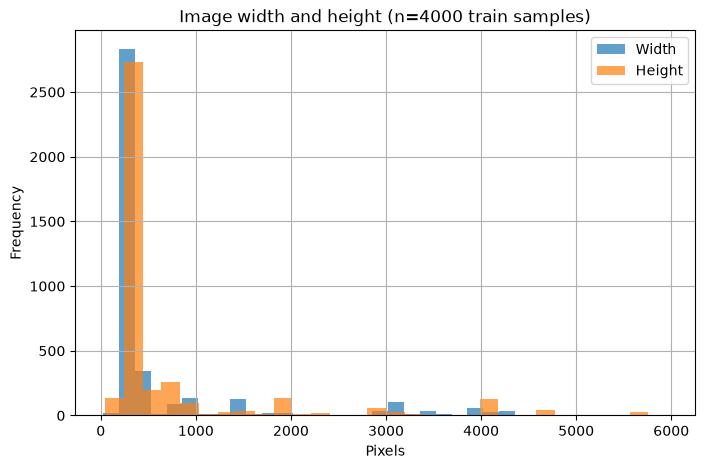

Saved: C:\Agroscan\models\Model_Comparison\03_image_size_histogram.png


In [12]:
sample_n = min(4000, len(train_df))
sample_paths = train_df.sample(n=sample_n, random_state=42)["filepath"].tolist()
widths, heights = [], []
for p in sample_paths:
    try:
        with Image.open(p) as im:
            w, h = im.size
        widths.append(w)
        heights.append(h)
    except Exception:
        pass

size_df = pd.DataFrame({"width": widths, "height": heights})
size_df.to_csv(SAVE_DIR / "image_size_sample.csv", index=False)

plt.figure(figsize=(8, 5))
plt.hist(widths, bins=30, alpha=0.7, label="Width")
plt.hist(heights, bins=30, alpha=0.7, label="Height")
plt.title(f"Image width and height (n={len(widths)} train samples)")
plt.xlabel("Pixels")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
path = SAVE_DIR / "03_image_size_histogram.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", path)

Cell 11: Graph 5 — Image size boxplot

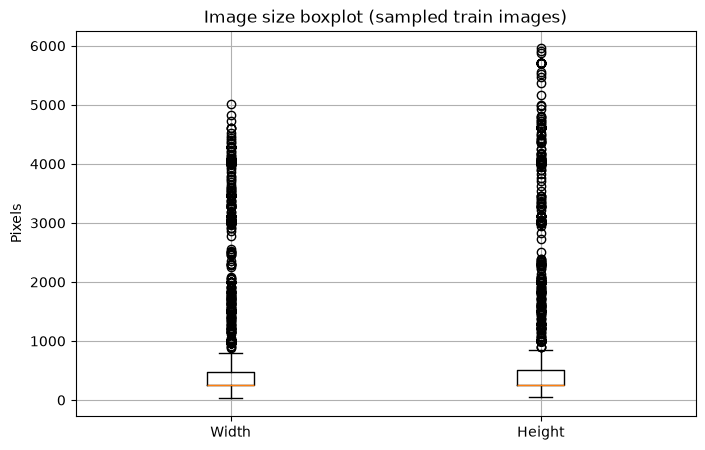

Saved: C:\Agroscan\models\Model_Comparison\04_image_size_boxplot.png


In [14]:
plt.figure(figsize=(8, 5))
plt.boxplot([widths, heights], tick_labels=["Width", "Height"])
plt.title("Image size boxplot (sampled train images)")
plt.ylabel("Pixels")
plt.grid(True)
path = SAVE_DIR / "04_image_size_boxplot.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", path)

Cell 12: Graph 6 — Sample images grid

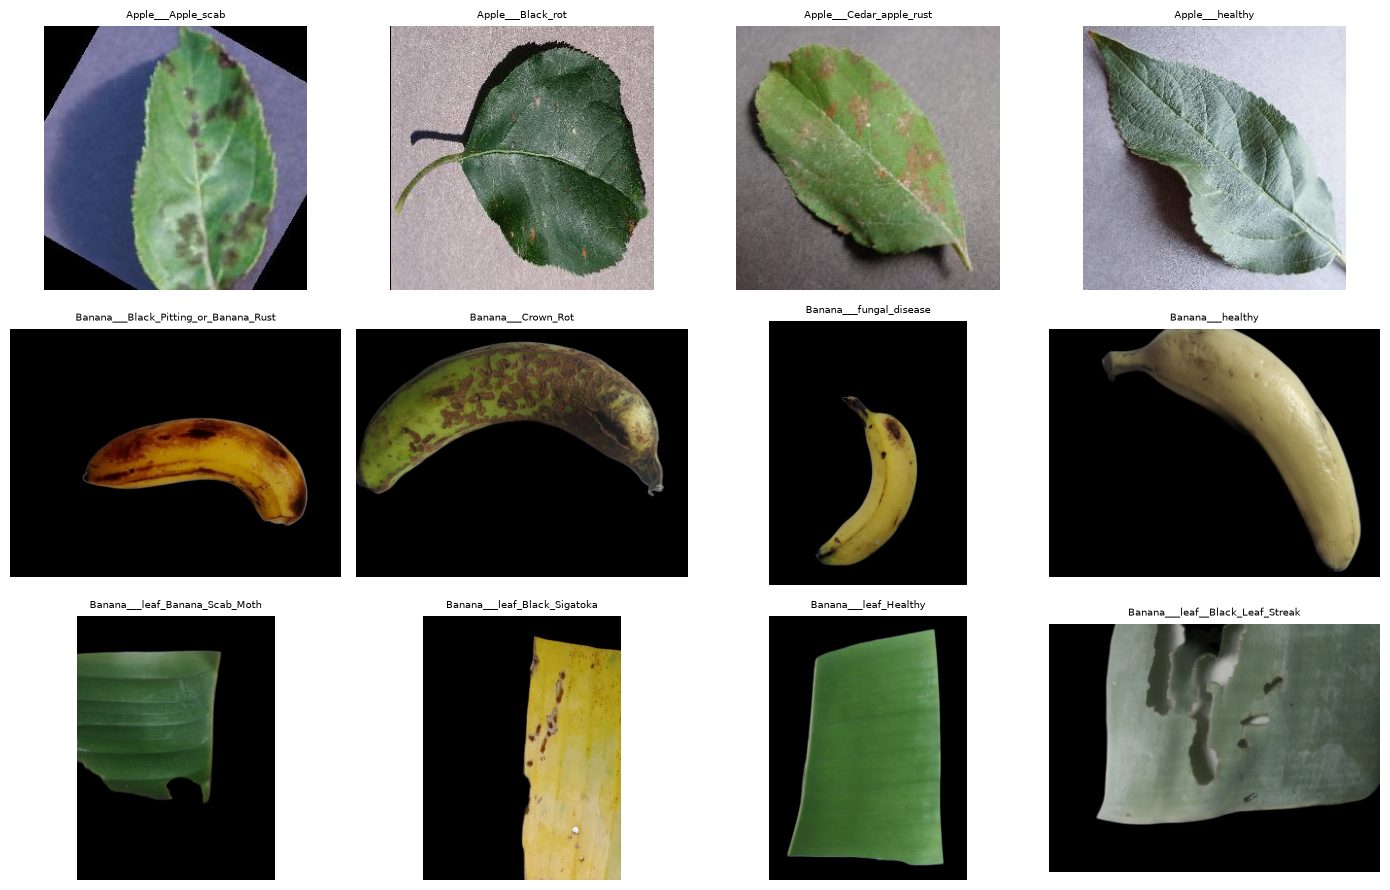

Saved: C:\Agroscan\models\Model_Comparison\05_sample_images_grid.png


In [15]:
sample_one = train_df.groupby("label").sample(n=1, random_state=42).head(12)

plt.figure(figsize=(14, 9))
for i, (_, row) in enumerate(sample_one.iterrows()):
    img = Image.open(row["filepath"]).convert("RGB")
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(row["label"], fontsize=7)
    plt.axis("off")
plt.tight_layout()
path = SAVE_DIR / "05_sample_images_grid.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", path)

Cell 13: Use existing train / valid / test splits (no re-split)

In [16]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "valid"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

print("Train:", len(train_df), "classes:", train_df["label"].nunique())
print("Valid:", len(val_df), "classes:", val_df["label"].nunique())
print("Test: ", len(test_df), "classes:", test_df["label"].nunique())

Train: 240865 classes: 123
Valid: 30046 classes: 123
Test:  30046 classes: 123


Cell 14: Transforms, Dataset, balanced sampler, focal loss

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms
import torchvision.models as tvm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
NUM_WORKERS = 0  # safest on Windows
SEED = 42
torch.manual_seed(SEED)

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
INPUT_SIZE = {
    "efficientnet_b3": 300,
    "resnet50": 224,
    "densenet121": 224,
}


def build_transforms(input_size: int, train: bool):
    if train:
        return transforms.Compose([
            transforms.RandomResizedCrop(input_size, scale=(0.7, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(20),
            transforms.ColorJitter(0.2, 0.2, 0.2),
            transforms.ToTensor(),
            transforms.Normalize(MEAN, STD),
        ])
    resize = int(input_size * 1.15)
    return transforms.Compose([
        transforms.Resize(resize),
        transforms.CenterCrop(input_size),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ])


class PlantDiseaseDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.targets = self.dataframe["label_idx"].astype(int).tolist()

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        label = int(row["label_idx"])
        if self.transform:
            image = self.transform(image)
        return image, label


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, target):
        w = self.weight.to(logits.device) if self.weight is not None else None
        ce = F.cross_entropy(logits, target, weight=w, reduction="none")
        pt = torch.exp(-ce)
        return (((1.0 - pt) ** self.gamma) * ce).mean()


def make_loader(dataframe, input_size, train: bool):
    ds = PlantDiseaseDataset(dataframe, build_transforms(input_size, train))
    if train:
        counts = np.bincount(ds.targets, minlength=num_classes).astype(np.float64)
        w_class = 1.0 / np.sqrt(np.maximum(counts, 1.0))
        sample_w = [float(w_class[t]) for t in ds.targets]
        sampler = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)
        return DataLoader(
            ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS,
            pin_memory=True, drop_last=True,
        )
    return DataLoader(
        ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
    )


print("Device:", DEVICE, "| classes:", num_classes)

Device: cuda | classes: 123


Cell 15: Model configs (AgroScan Level-3 ensemble)

In [18]:
MODEL_CONFIGS = {
    "EfficientNet_B3": {"arch": "efficientnet_b3", "save_name": "efficientnet_b3"},
    "ResNet50": {"arch": "resnet50", "save_name": "resnet50"},
    "DenseNet121": {"arch": "densenet121", "save_name": "densenet121"},
}


def build_model(arch, num_classes, pretrained=True):
    weights = "DEFAULT" if pretrained else None
    if arch == "efficientnet_b3":
        m = tvm.efficientnet_b3(weights=weights)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    elif arch == "resnet50":
        m = tvm.resnet50(weights=weights)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif arch == "densenet121":
        m = tvm.densenet121(weights=weights)
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    else:
        raise ValueError(arch)
    return m


def freeze_backbone_train_head(model, arch):
    for p in model.parameters():
        p.requires_grad = False
    if arch == "resnet50":
        for p in model.fc.parameters():
            p.requires_grad = True
    elif arch == "densenet121":
        for p in model.classifier.parameters():
            p.requires_grad = True
    else:
        for p in model.classifier.parameters():
            p.requires_grad = True


def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True

Cell 16: Training / eval step functions

In [19]:
from tqdm import tqdm
import torch.optim as optim

criterion = FocalLoss(gamma=2.0)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = correct = total = 0
    use_amp = device.startswith("cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    for images, labels in tqdm(loader, desc="Training"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    return total_loss / max(total, 1), correct / max(total, 1)


def evaluate_one_epoch(model, loader, criterion, device, mode="Validation"):
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc=mode):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return total_loss / max(total, 1), correct / max(total, 1)

Cell 17: Train one model (head-only then full fine-tune)

In [20]:
def train_model(model_key, config, phase1_epochs=2, phase2_epochs=4):
    print("\n" + "=" * 70)
    print("Training:", model_key)
    print("=" * 70)

    arch = config["arch"]
    img_size = INPUT_SIZE[arch]
    model_dir = SAVE_DIR / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    best_model_path = model_dir / f"{config['save_name']}_best_model.pt"
    final_model_path = model_dir / f"{config['save_name']}_final_model.pt"
    history_path = model_dir / f"{config['save_name']}_history.csv"

    train_loader = make_loader(train_df, img_size, True)
    val_loader = make_loader(val_df, img_size, False)

    model = build_model(arch, num_classes, pretrained=True).to(DEVICE)
    history = {"epoch": [], "phase": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0

    def maybe_save(val_acc):
        nonlocal best_val_acc
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                "model_key": model_key,
                "arch": arch,
                "model_state_dict": model.state_dict(),
                "class_names": class_names,
                "label_to_idx": label_to_idx,
                "num_classes": num_classes,
                "img_size": img_size,
                "val_acc": val_acc,
            }, best_model_path)
            print("Best model saved.", float(val_acc))

    freeze_backbone_train_head(model, arch)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)
    for epoch in range(phase1_epochs):
        print(f"\n{model_key} | Phase 1 | Epoch {epoch+1}/{phase1_epochs}")
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        va_loss, va_acc = evaluate_one_epoch(model, val_loader, criterion, DEVICE)
        history["epoch"].append(epoch + 1)
        history["phase"].append("head_only")
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        print(f"Train {tr_loss:.4f}/{tr_acc:.4f}  Val {va_loss:.4f}/{va_acc:.4f}")
        maybe_save(va_acc)

    unfreeze_all(model)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=phase2_epochs)
    start = len(history["epoch"])
    for epoch in range(phase2_epochs):
        print(f"\n{model_key} | Phase 2 | Epoch {epoch+1}/{phase2_epochs}")
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        va_loss, va_acc = evaluate_one_epoch(model, val_loader, criterion, DEVICE)
        scheduler.step()
        history["epoch"].append(start + epoch + 1)
        history["phase"].append("full_finetune")
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        print(f"Train {tr_loss:.4f}/{tr_acc:.4f}  Val {va_loss:.4f}/{va_acc:.4f}")
        maybe_save(va_acc)

    torch.save({
        "model_key": model_key,
        "arch": arch,
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "label_to_idx": label_to_idx,
        "num_classes": num_classes,
        "img_size": img_size,
        "best_val_acc": best_val_acc,
    }, final_model_path)
    pd.DataFrame(history).to_csv(history_path, index=False)
    print("Done", model_key, "best val_acc", best_val_acc)
    return {
        "model_key": model_key,
        "arch": arch,
        "history_path": str(history_path),
        "best_model_path": str(best_model_path),
        "final_model_path": str(final_model_path),
        "best_val_acc": best_val_acc,
        "img_size": img_size,
    }

In [21]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = correct = total = 0
    use_amp = device.startswith("cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    for images, labels in tqdm(loader, desc="Training"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    return total_loss / max(total, 1), correct / max(total, 1)

Cell 18: Train all 3 models (or reuse saved checkpoints)

In [30]:
training_results = []

if RUN_TRAINING:
    for model_key, config in MODEL_CONFIGS.items():
        training_results.append(train_model(model_key, config, phase1_epochs=2, phase2_epochs=4))
else:
    for model_key, config in MODEL_CONFIGS.items():
        model_dir = SAVE_DIR / model_key
        best_model_path = model_dir / f"{config['save_name']}_best_model.pt"
        history_path = model_dir / f"{config['save_name']}_history.csv"
        if not best_model_path.exists():
            print("Missing checkpoint:", best_model_path)
            continue
        training_results.append({
            "model_key": model_key,
            "arch": config["arch"],
            "history_path": str(history_path) if history_path.exists() else None,
            "best_model_path": str(best_model_path),
            "final_model_path": str(model_dir / f"{config['save_name']}_final_model.pt"),
            "best_val_acc": None,
            "img_size": INPUT_SIZE[config["arch"]],
        })

training_results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "all_probs"} for r in training_results
])
training_results_df.to_csv(SAVE_DIR / "training_results_summary.csv", index=False)
training_results_df


Training: EfficientNet_B3

EfficientNet_B3 | Phase 1 | Epoch 1/2


Validation: 100%|██████████| 939/939 [05:27<00:00,  2.86it/s]


Train 0.4344/0.8037  Val 0.4072/0.8881
Best model saved. 0.8881381881115623

EfficientNet_B3 | Phase 1 | Epoch 2/2


Validation: 100%|██████████| 939/939 [05:28<00:00,  2.86it/s]


Train 0.2747/0.8386  Val 0.3518/0.8944
Best model saved. 0.8943952606004127

EfficientNet_B3 | Phase 2 | Epoch 1/4


...

Validation: 100%|██████████| 939/939 [05:23<00:00,  2.90it/s]


Train 0.0374/0.9655  Val 0.0437/0.9672
Best model saved. 0.9671836517340079

DenseNet121 | Phase 2 | Epoch 4/4


Validation: 100%|██████████| 939/939 [05:01<00:00,  3.11it/s]


Train 0.0203/0.9778  Val 0.0323/0.9748
Best model saved. 0.9748052985422352
Done DenseNet121 best val_acc 0.9748052985422352


,model_key,arch,history_path,best_model_path,final_model_path,best_val_acc,img_size
0,EfficientNet_B3,efficientnet_b3,C:\Agroscan\models\Model_Comparison\EfficientN...,C:\Agroscan\models\Model_Comparison\EfficientN...,C:\Agroscan\models\Model_Comparison\EfficientN...,0.979032,300
1,ResNet50,resnet50,C:\Agroscan\models\Model_Comparison\ResNet50\r...,C:\Agroscan\models\Model_Comparison\ResNet50\r...,C:\Agroscan\models\Model_Comparison\ResNet50\r...,0.977068,224
2,DenseNet121,densenet121,C:\Agroscan\models\Model_Comparison\DenseNet12...,C:\Agroscan\models\Model_Comparison\DenseNet12...,C:\Agroscan\models\Model_Comparison\DenseNet12...,0.974805,224


Part E: Individual training graphs

Cell 19: Accuracy and loss curves

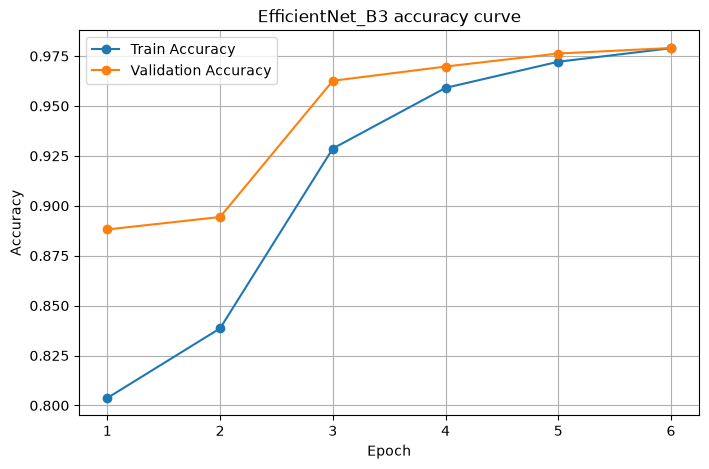

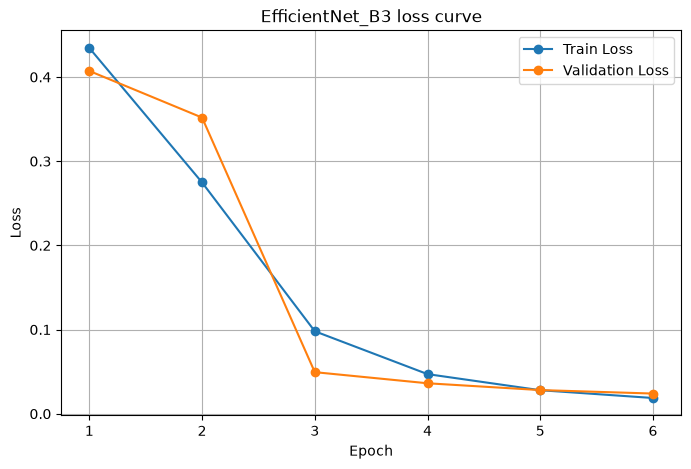

Saved: C:\Agroscan\models\Model_Comparison\EfficientNet_B3\EfficientNet_B3_accuracy_curve.png
Saved: C:\Agroscan\models\Model_Comparison\EfficientNet_B3\EfficientNet_B3_loss_curve.png


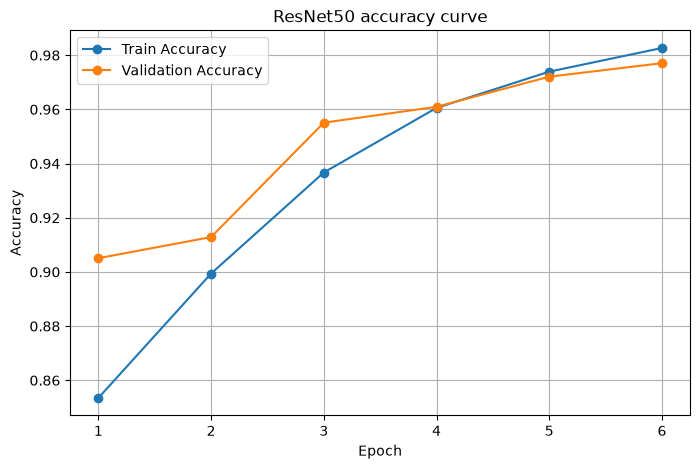

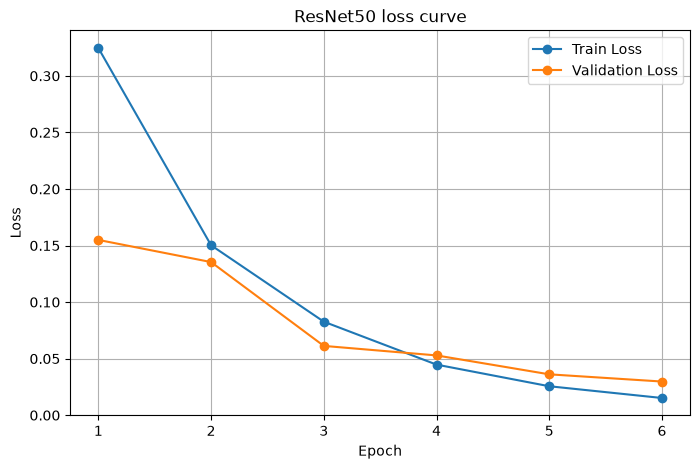

Saved: C:\Agroscan\models\Model_Comparison\ResNet50\ResNet50_accuracy_curve.png
Saved: C:\Agroscan\models\Model_Comparison\ResNet50\ResNet50_loss_curve.png


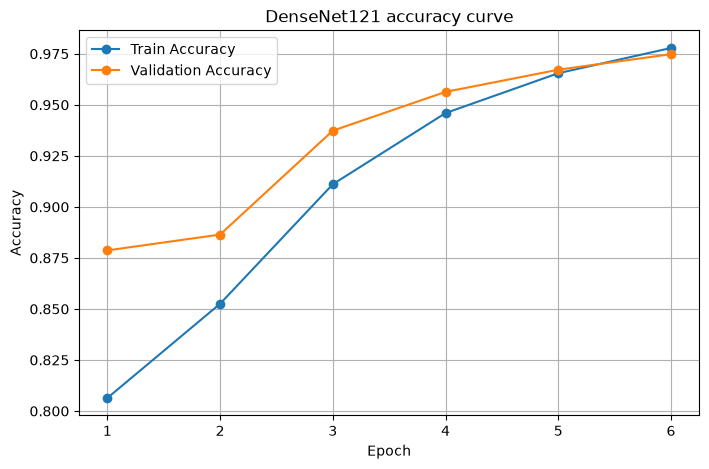

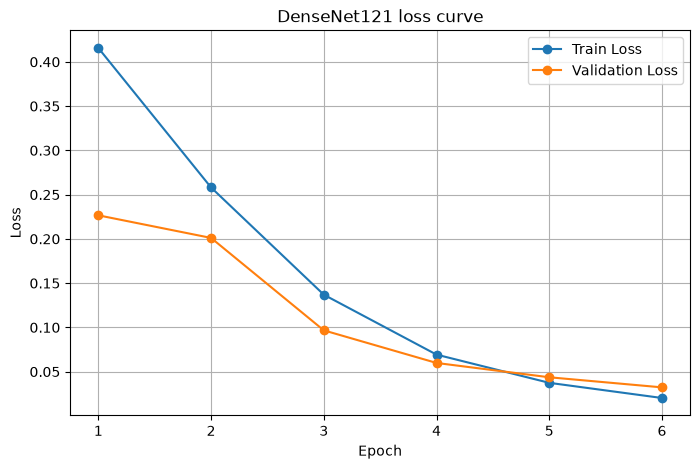

Saved: C:\Agroscan\models\Model_Comparison\DenseNet121\DenseNet121_accuracy_curve.png
Saved: C:\Agroscan\models\Model_Comparison\DenseNet121\DenseNet121_loss_curve.png


In [31]:
def plot_training_curves(model_key, history_path):
    if not history_path or not Path(history_path).exists():
        print("No history for", model_key)
        return
    model_dir = SAVE_DIR / model_key
    history_df = pd.read_csv(history_path)

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train Accuracy")
    plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_key} accuracy curve")
    plt.legend()
    plt.grid(True)
    acc_path = model_dir / f"{model_key}_accuracy_curve.png"
    plt.savefig(acc_path, dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_key} loss curve")
    plt.legend()
    plt.grid(True)
    loss_path = model_dir / f"{model_key}_loss_curve.png"
    plt.savefig(loss_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", acc_path)
    print("Saved:", loss_path)


for item in training_results:
    plot_training_curves(item["model_key"], item.get("history_path"))

Part F: Evaluation metrics

Cell 20: Evaluate best model on test data

In [32]:
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
)
import time


def load_best_model(best_model_path):
    checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
    arch = checkpoint.get("arch") or checkpoint.get("timm_name")
    model = build_model(arch, checkpoint["num_classes"], pretrained=False)
    state = checkpoint.get("model_state_dict") or checkpoint.get("state_dict")
    model.load_state_dict(state)
    model = model.to(DEVICE).eval()
    return model, checkpoint


def evaluate_best_model(model_key, best_model_path, img_size):
    model, checkpoint = load_best_model(best_model_path)
    test_loader = make_loader(test_df, img_size, False)
    all_preds, all_labels, all_probs = [], [], []
    start_time = time.time()
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Testing {model_key}"):
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    total_time = time.time() - start_time
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    report = classification_report(
        all_labels, all_preds, target_names=class_names, digits=4, zero_division=0
    )
    model_dir = SAVE_DIR / model_key
    report_path = model_dir / f"{model_key}_classification_report.txt"
    report_path.write_text(report, encoding="utf-8")
    print("\n", model_key)
    print(report)
    return {
        "model_key": model_key,
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "avg_inference_time": total_time / max(len(test_df), 1),
        "all_labels": all_labels,
        "all_preds": all_preds,
        "all_probs": all_probs,
        "report_path": str(report_path),
    }


evaluation_results = []
for item in training_results:
    evaluation_results.append(
        evaluate_best_model(item["model_key"], item["best_model_path"], item["img_size"])
    )

Testing EfficientNet_B3: 100%|██████████| 939/939 [07:37<00:00,  2.05it/s]



 EfficientNet_B3
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9938    0.9877    0.9907       324
                                 Apple___Black_rot     1.0000    1.0000    1.0000       310
                          Apple___Cedar_apple_rust     0.9843    0.9804    0.9823       255
                                   Apple___healthy     0.9906    0.9906    0.9906       424
             Banana___Black_Pitting_or_Banana_Rust     0.6971    0.7323    0.7143       396
                                Banana___Crown_Rot     0.6842    0.9286    0.7879        28
                           Banana___fungal_disease     0.6429    0.5426    0.5885       282
                                  Banana___healthy     0.5000    0.8824    0.6383        17
                    Banana___leaf_Banana_Scab_Moth     1.0000    0.9000    0.9474        10
                      Banana___leaf_Black_Sigatoka     0.8667

Testing ResNet50: 100%|██████████| 939/939 [04:19<00:00,  3.62it/s]



 ResNet50
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9877    0.9938       324
                                 Apple___Black_rot     1.0000    1.0000    1.0000       310
                          Apple___Cedar_apple_rust     0.9921    0.9882    0.9902       255
                                   Apple___healthy     0.9976    0.9929    0.9953       424
             Banana___Black_Pitting_or_Banana_Rust     0.7580    0.6566    0.7037       396
                                Banana___Crown_Rot     0.7742    0.8571    0.8136        28
                           Banana___fungal_disease     0.6340    0.6879    0.6599       282
                                  Banana___healthy     0.3902    0.9412    0.5517        17
                    Banana___leaf_Banana_Scab_Moth     1.0000    0.9000    0.9474        10
                      Banana___leaf_Black_Sigatoka     0.8873    0.7

Testing DenseNet121: 100%|██████████| 939/939 [04:19<00:00,  3.61it/s]



 DenseNet121
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9938    0.9846    0.9891       324
                                 Apple___Black_rot     1.0000    1.0000    1.0000       310
                          Apple___Cedar_apple_rust     0.9767    0.9843    0.9805       255
                                   Apple___healthy     0.9906    0.9976    0.9941       424
             Banana___Black_Pitting_or_Banana_Rust     0.7745    0.5379    0.6349       396
                                Banana___Crown_Rot     0.5854    0.8571    0.6957        28
                           Banana___fungal_disease     0.5871    0.7766    0.6687       282
                                  Banana___healthy     0.4375    0.8235    0.5714        17
                    Banana___leaf_Banana_Scab_Moth     1.0000    1.0000    1.0000        10
                      Banana___leaf_Black_Sigatoka     1.0000    

Cell 21: Save evaluation summary

In [33]:
summary_rows = []
for result in evaluation_results:
    summary_rows.append({
        "Model": result["model_key"],
        "Accuracy": result["accuracy"],
        "Precision_macro": result["precision_macro"],
        "Recall_macro": result["recall_macro"],
        "F1_macro": result["f1_macro"],
        "Avg_Inference_Time_Per_Image": result["avg_inference_time"],
    })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(SAVE_DIR / "evaluation_summary.csv", index=False)
summary_df

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,Avg_Inference_Time_Per_Image
0,EfficientNet_B3,0.979232,0.947964,0.953416,0.948318,0.015221
1,ResNet50,0.979165,0.953911,0.957094,0.953283,0.008626
2,DenseNet121,0.975671,0.945577,0.949451,0.943561,0.008652


Part G: Comparison graphs

Cell 22: Model accuracy comparison

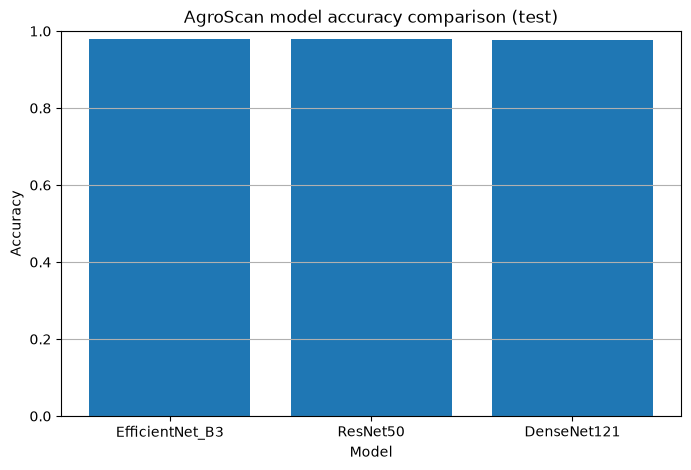

Saved: C:\Agroscan\models\Model_Comparison\06_model_accuracy_comparison.png


In [34]:
plt.figure(figsize=(8, 5))
plt.bar(summary_df["Model"], summary_df["Accuracy"])
plt.title("AgroScan model accuracy comparison (test)")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y")
path = SAVE_DIR / "06_model_accuracy_comparison.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", path)

Cell 23: Precision, recall, F1 comparison

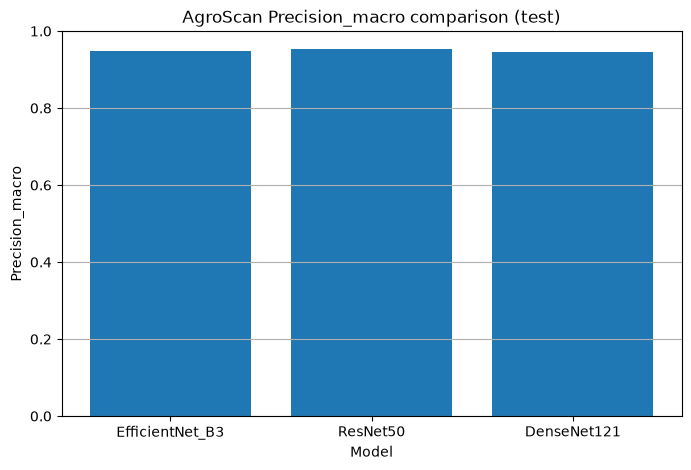

Saved: C:\Agroscan\models\Model_Comparison\07_Precision_macro_comparison.png


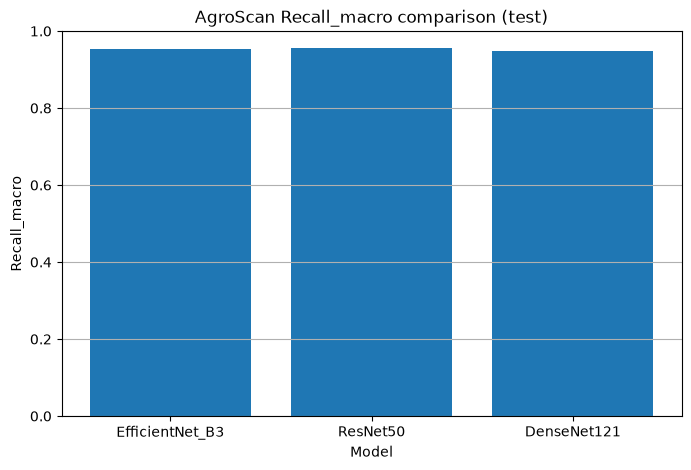

Saved: C:\Agroscan\models\Model_Comparison\07_Recall_macro_comparison.png


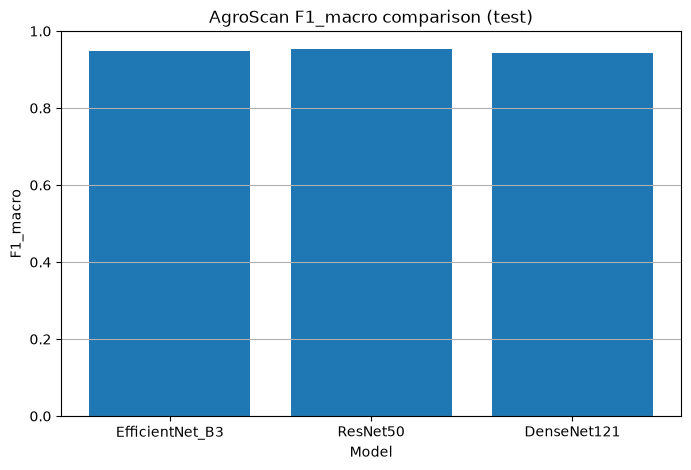

Saved: C:\Agroscan\models\Model_Comparison\07_F1_macro_comparison.png


In [35]:
for metric in ["Precision_macro", "Recall_macro", "F1_macro"]:
    plt.figure(figsize=(8, 5))
    plt.bar(summary_df["Model"], summary_df[metric])
    plt.title(f"AgroScan {metric} comparison (test)")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.grid(axis="y")
    path = SAVE_DIR / f"07_{metric}_comparison.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

Cell 24: Combined metrics comparison

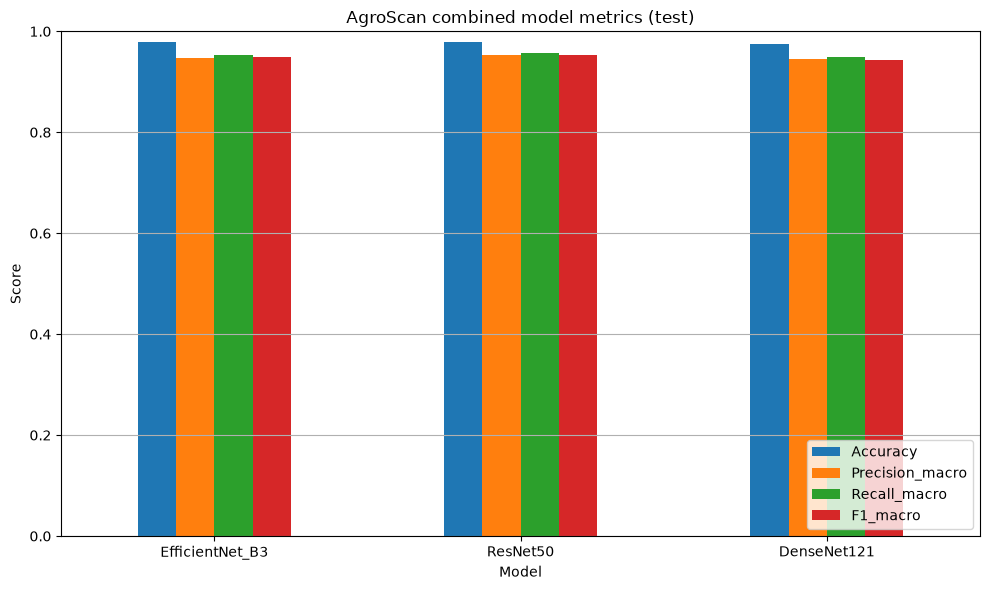

Saved: C:\Agroscan\models\Model_Comparison\08_combined_metrics_comparison.png


In [36]:
plot_df = summary_df.set_index("Model")[["Accuracy", "Precision_macro", "Recall_macro", "F1_macro"]]
plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("AgroScan combined model metrics (test)")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(loc="lower right")
plt.tight_layout()
path = SAVE_DIR / "08_combined_metrics_comparison.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", path)

Cell 25: Confusion matrix for each model

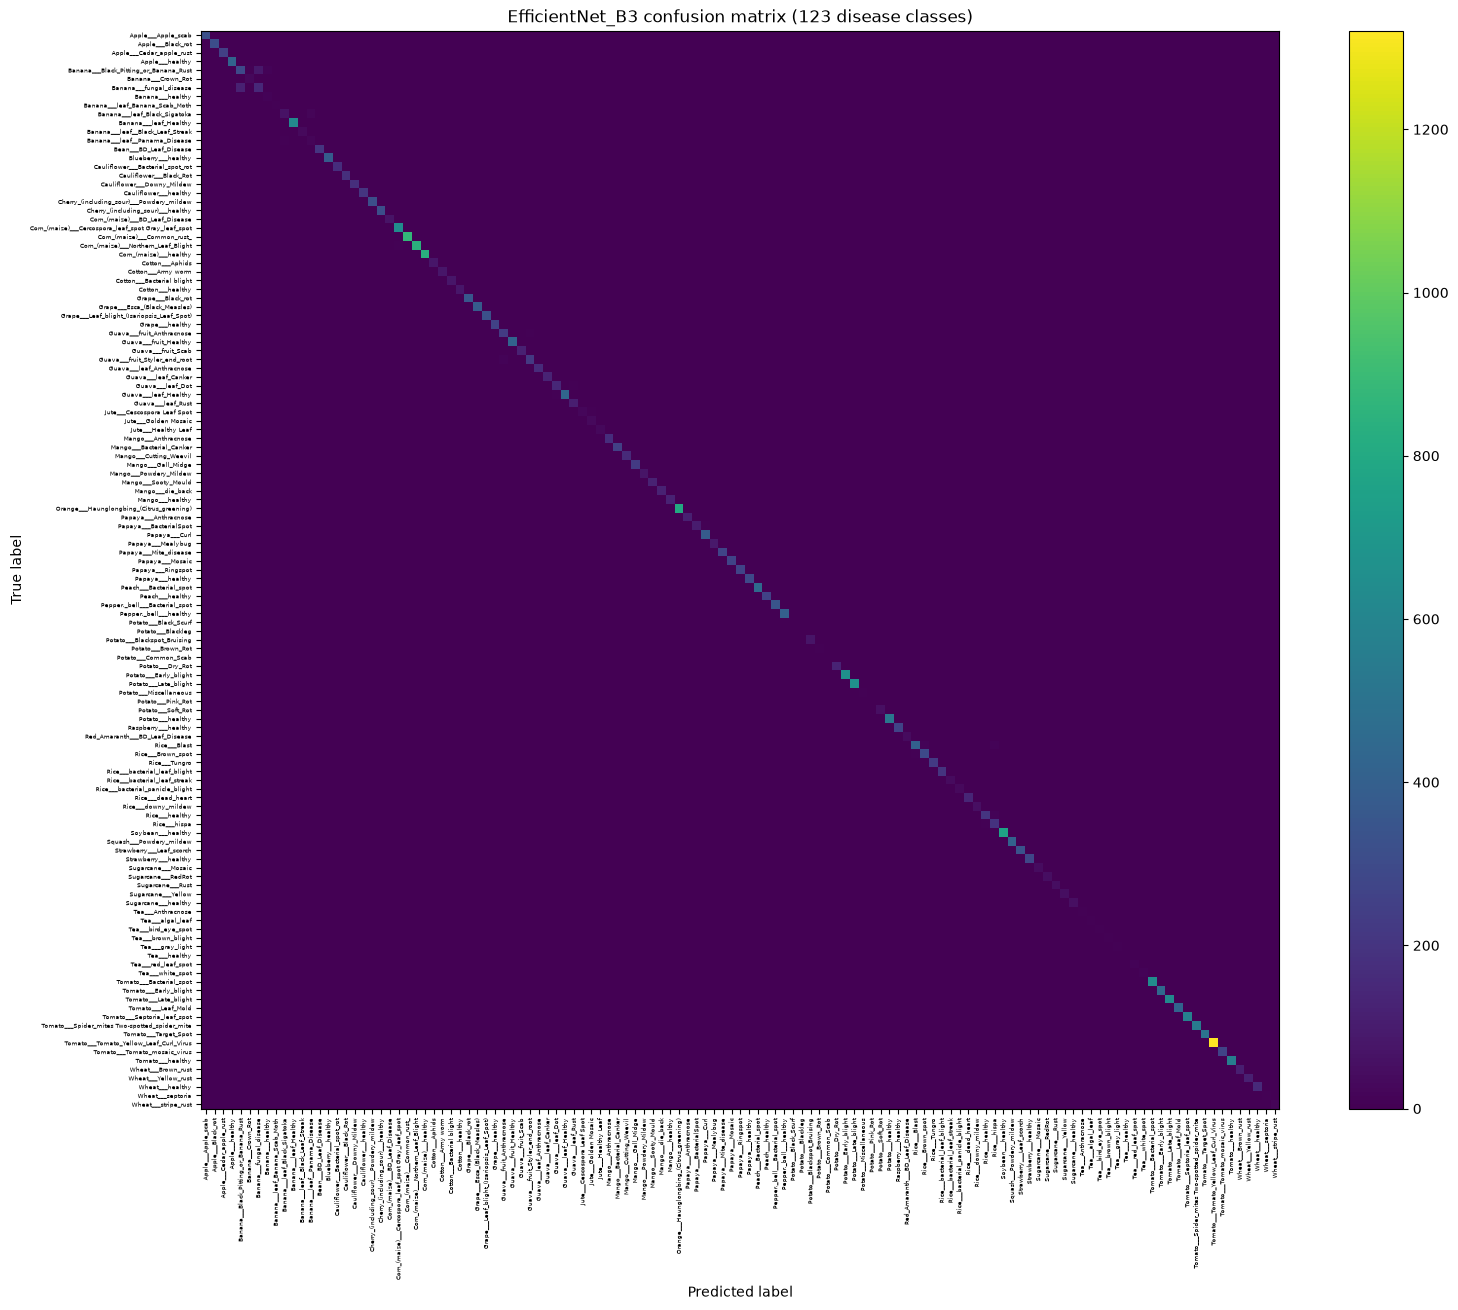

Saved: C:\Agroscan\models\Model_Comparison\EfficientNet_B3\EfficientNet_B3_confusion_matrix.png


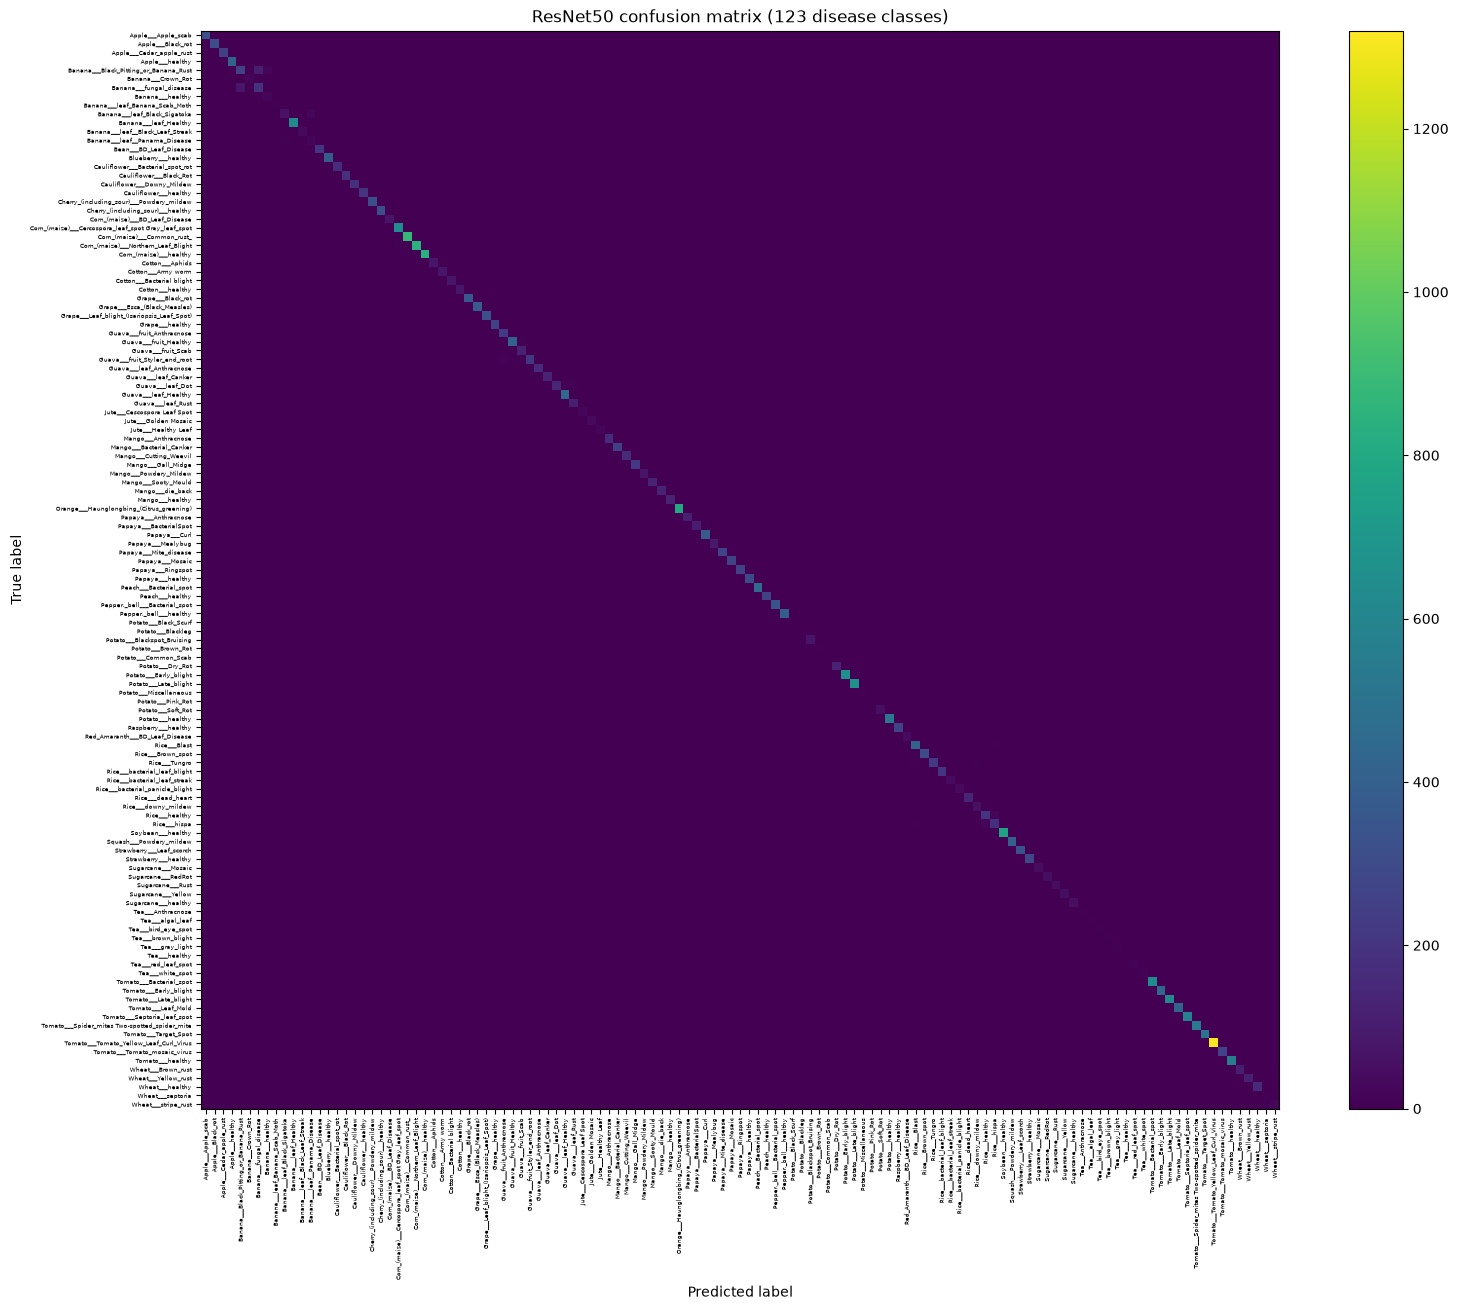

Saved: C:\Agroscan\models\Model_Comparison\ResNet50\ResNet50_confusion_matrix.png


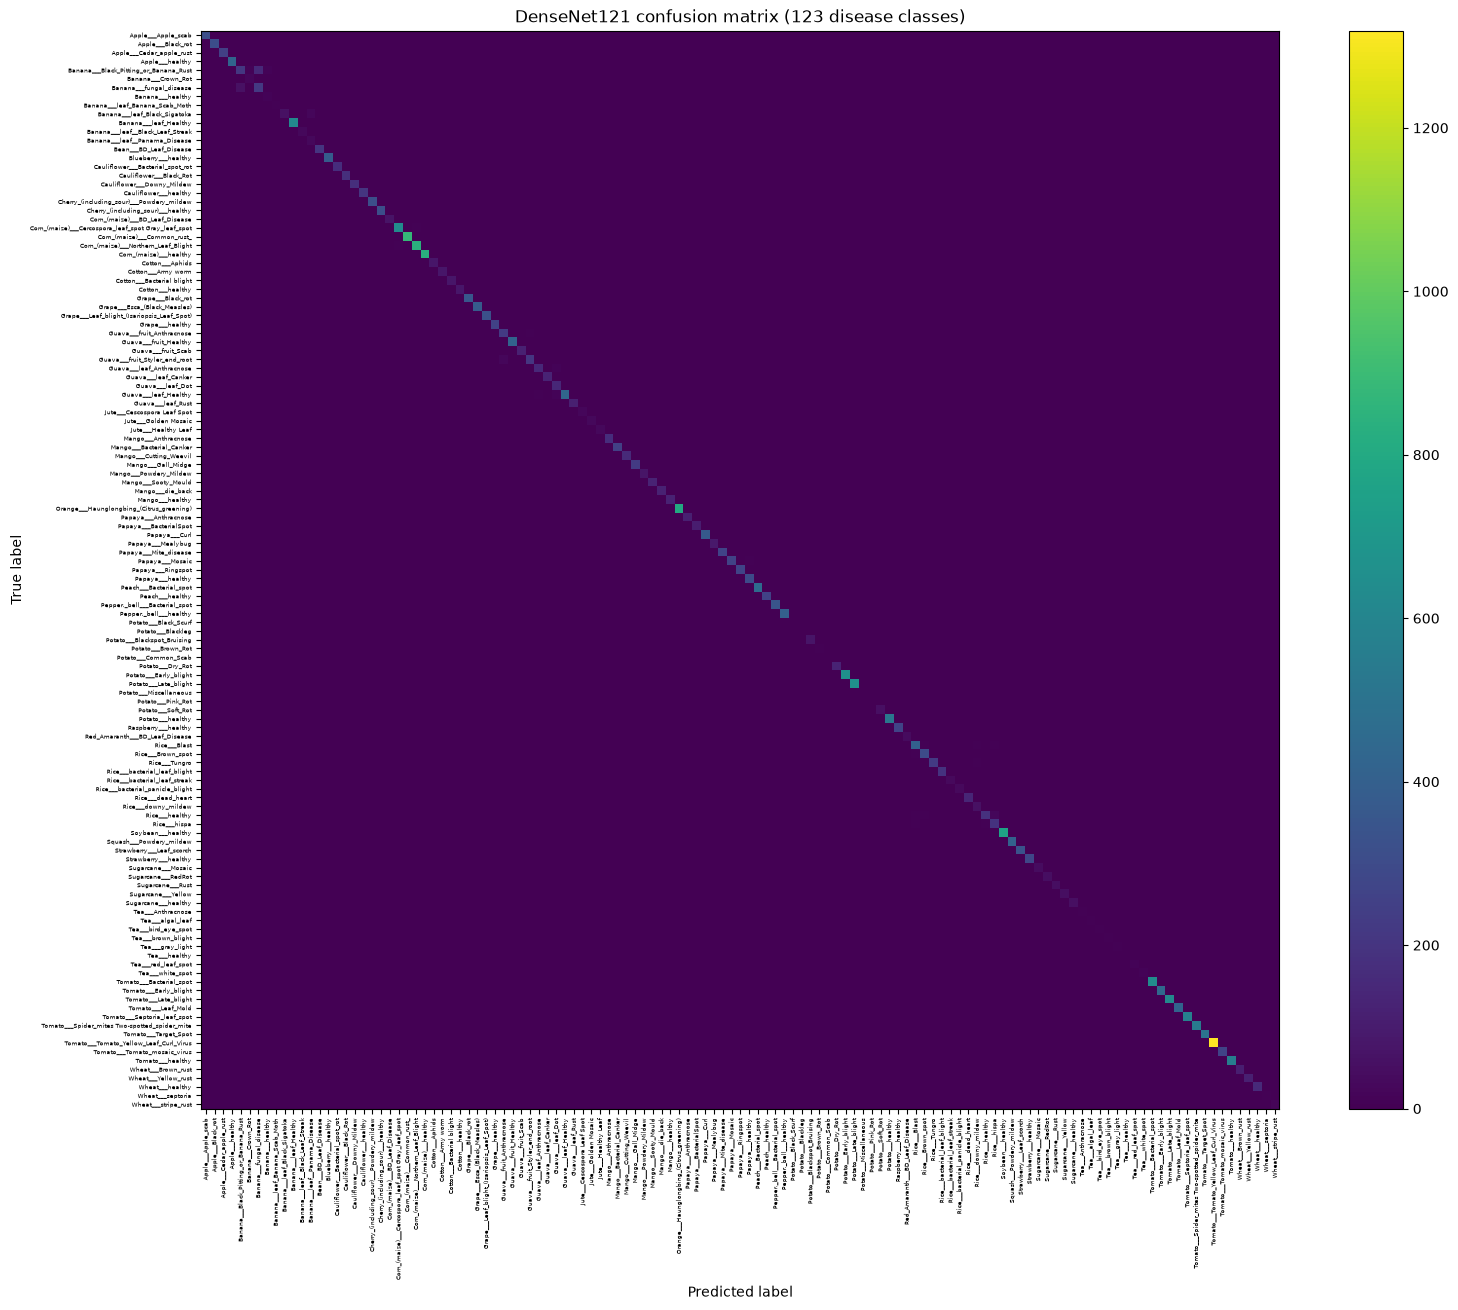

Saved: C:\Agroscan\models\Model_Comparison\DenseNet121\DenseNet121_confusion_matrix.png


In [37]:
for result in evaluation_results:
    model_key = result["model_key"]
    cm = confusion_matrix(result["all_labels"], result["all_preds"])
    plt.figure(figsize=(18, 14))
    plt.imshow(cm)
    plt.title(f"{model_key} confusion matrix (123 disease classes)")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.colorbar()
    plt.xticks(range(len(class_names)), class_names, rotation=90, fontsize=4)
    plt.yticks(range(len(class_names)), class_names, fontsize=4)
    path = SAVE_DIR / model_key / f"{model_key}_confusion_matrix.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

Cell 26: Multi-class ROC (micro-average)

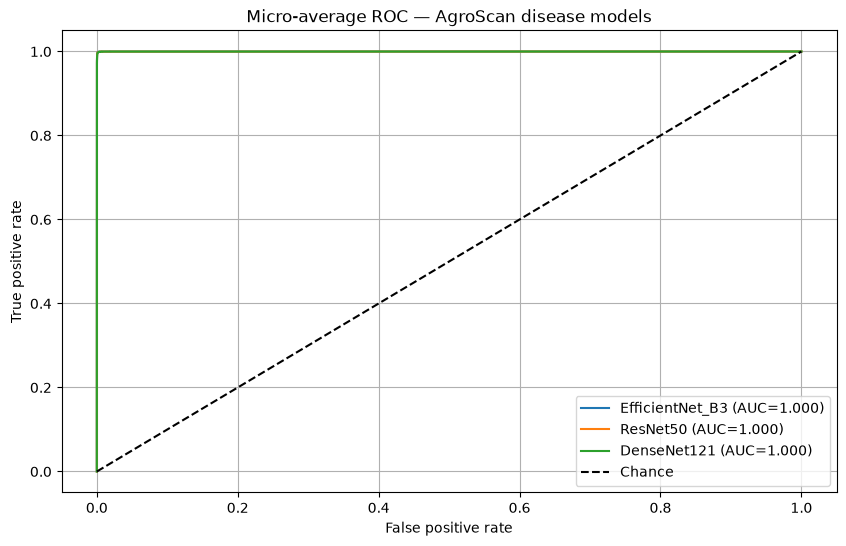

Saved: C:\Agroscan\models\Model_Comparison\09_roc_comparison.png


In [38]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(test_df["label_idx"], classes=list(range(num_classes)))

plt.figure(figsize=(10, 6))
for result in evaluation_results:
    y_score = result["all_probs"]
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{result['model_key']} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Micro-average ROC — AgroScan disease models")
plt.legend()
plt.grid(True)
path = SAVE_DIR / "09_roc_comparison.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", path)

Cell 27: Precision-Recall curve comparison

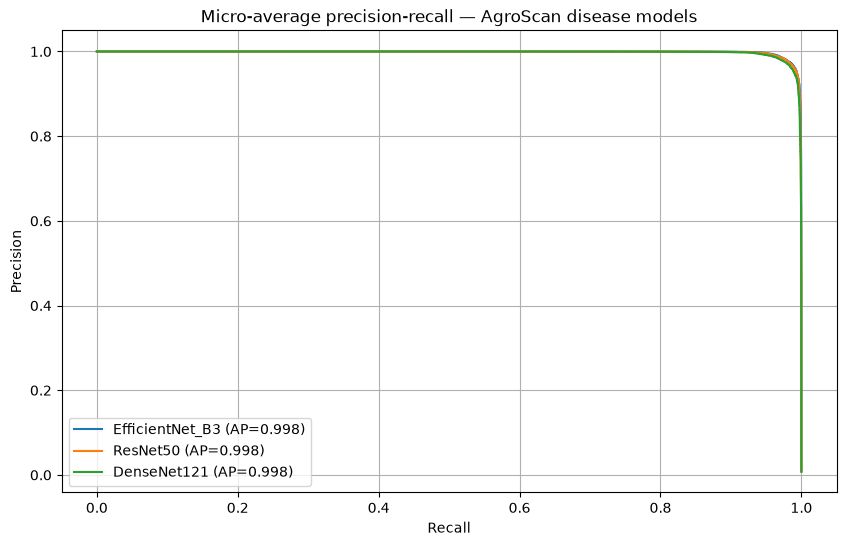

Saved: C:\Agroscan\models\Model_Comparison\10_pr_comparison.png


In [39]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 6))
for result in evaluation_results:
    y_score = result["all_probs"]
    precision, recall, _ = precision_recall_curve(y_test_bin.ravel(), y_score.ravel())
    avg_precision = average_precision_score(y_test_bin, y_score, average="micro")
    plt.plot(recall, precision, label=f"{result['model_key']} (AP={avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Micro-average precision-recall — AgroScan disease models")
plt.legend()
plt.grid(True)
path = SAVE_DIR / "10_pr_comparison.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", path)

Part I: Model size and speed

Cell 28: Model size comparison

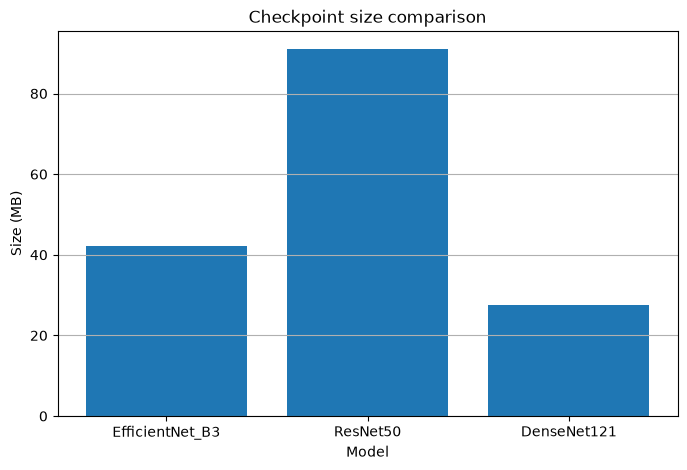

Saved: C:\Agroscan\models\Model_Comparison\11_model_size_comparison.png


,Model,Model_Size_MB
0,EfficientNet_B3,42.068813
1,ResNet50,90.948763
2,DenseNet121,27.599633


In [40]:
model_size_rows = []
for item in training_results:
    size_mb = os.path.getsize(item["best_model_path"]) / (1024 * 1024)
    model_size_rows.append({"Model": item["model_key"], "Model_Size_MB": size_mb})
size_df = pd.DataFrame(model_size_rows)
plt.figure(figsize=(8, 5))
plt.bar(size_df["Model"], size_df["Model_Size_MB"])
plt.title("Checkpoint size comparison")
plt.xlabel("Model")
plt.ylabel("Size (MB)")
plt.grid(axis="y")
path = SAVE_DIR / "11_model_size_comparison.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", path)
size_df

Cell 29: Inference time comparison

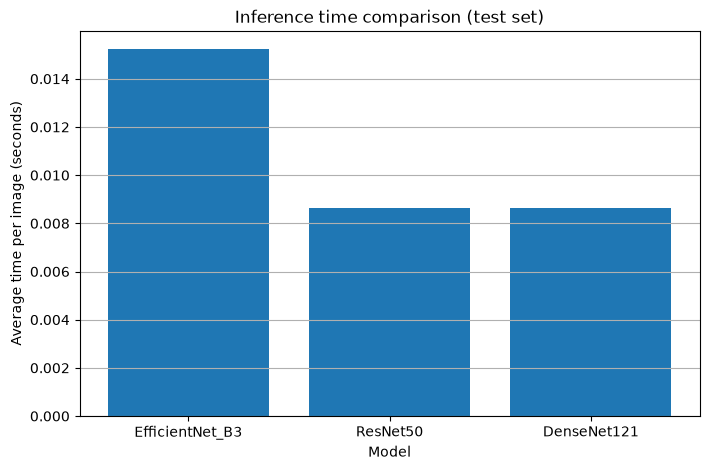

Saved: C:\Agroscan\models\Model_Comparison\12_inference_time_comparison.png


In [41]:
plt.figure(figsize=(8, 5))
plt.bar(summary_df["Model"], summary_df["Avg_Inference_Time_Per_Image"])
plt.title("Inference time comparison (test set)")
plt.xlabel("Model")
plt.ylabel("Average time per image (seconds)")
plt.grid(axis="y")
path = SAVE_DIR / "12_inference_time_comparison.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", path)

Cell 30: Sample image for Grad-CAM

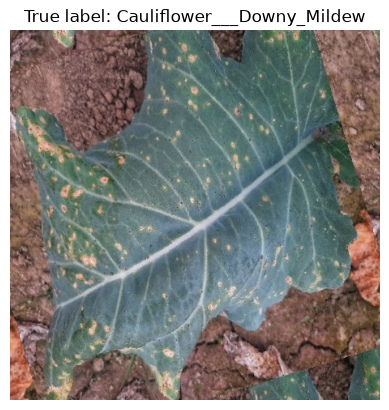

C:\Agroscan\Datasets\test\Cauliflower___Downy_Mildew\00001595_train_014026.jpg


In [42]:
sample_row = test_df.sample(1, random_state=10).iloc[0]
sample_img_path = sample_row["filepath"]
sample_true_label = sample_row["label"]
img = Image.open(sample_img_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.title(f"True label: {sample_true_label}")
plt.show()
print(sample_img_path)

Cell 31: Grad-CAM for torchvision backbones

In [ ]:
%pip install grad-cam

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53402 sha256=58152ebac0fbbd30d1fe3b85d784bd28cfb212cc7e8cd1aec65baab6d6deed0d
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\05\bd\e2\0c0eecf3c26b6cdb231b5656d53905bddc8090d69619d57e6b
Successfully built grad-cam

   ---------------------------------------- 2/2 [grad-cam]

Note: you may need to restart the kernel to use updated packages.


In [1]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


def get_target_layer(model, arch):
    if arch == "resnet50":
        return model.layer4[-1]
    if arch == "densenet121":
        return model.features.denseblock4
    if arch == "efficientnet_b3":
        return model.features[-1]
    raise RuntimeError(f"No Grad-CAM layer for {arch}")


def generate_gradcam(model_key, best_model_path, image_path, img_size, arch):
    model, checkpoint = load_best_model(best_model_path)
    xai_transform = transforms.Compose([
        transforms.Resize(int(img_size * 1.15)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ])
    img = Image.open(image_path).convert("RGB")
    raw_img = img.resize((img_size, img_size))
    rgb_img = np.array(raw_img).astype(np.float32) / 255.0
    input_tensor = xai_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = F.softmax(outputs, dim=1)[0]
        predicted_class = int(outputs.argmax(dim=1).item())
        confidence = float(probs[predicted_class].item() * 100)
    cam = GradCAM(model=model, target_layers=[get_target_layer(model, arch)])
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(predicted_class)])[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(raw_img)
    plt.axis("off")
    plt.title("Original")
    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.axis("off")
    plt.title(f"{model_key}: {class_names[predicted_class]} ({confidence:.1f}%)")
    path = SAVE_DIR / model_key / f"{model_key}_gradcam_sample.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Predicted:", class_names[predicted_class], "conf", round(confidence, 2), "%")
    print("Saved:", path)

Cell 32: Grad-CAM for all compared models

In [2]:
for item in training_results:
    generate_gradcam(
        item["model_key"],
        item["best_model_path"],
        sample_img_path,
        item["img_size"],
        item["arch"],
    )

NameError: name 'training_results' is not defined

## Outputs

All figures, CSVs, classification reports, and checkpoints land in:

`I:\AgroScan\models\Model_Comparison\`

To skip retraining next time, set `RUN_TRAINING = False` in Cell 3 after the first successful run.